## Short 
Diego Dueñas Martín  
751426  
09/02/2026

## Ejercicio de long y short

## Contexto del ejercicio

Este notebook compara dos formas de pensar el pago (payoff) de opciones financieras tipo call y put:

- Un primer acercamiento ingenuo, donde el precio del subyacente al vencimiento se genera con una distribución uniforme, solo para visualizar la forma de las funciones de pago.
- Un segundo acercamiento, ya en la sección de trabajo en equipo, donde el precio se simula con Movimiento Browniano Geométrico (GBM) bajo la medida neutral al riesgo —el modelo detrás de Black-Scholes— y se usa para estimar la ganancia esperada de call y put bajo distintos escenarios de volatilidad, tasa y plazo.

### Diccionario rápido

| Término | Significado |
|---|---|
| $S$ | Precio spot (actual) del subyacente |
| $S_T$ | Precio del subyacente al vencimiento (variable aleatoria) |
| $K$ | Precio strike (precio de ejercicio) |
| $r$ | Tasa libre de riesgo |
| $\sigma$ | Volatilidad anualizada del subyacente |
| $T$ | Tiempo a vencimiento, en años |
| $M$ | Número de simulaciones Monte Carlo |
| Call | Opción que paga $\max(S_T - K, 0)$ |
| Put | Opción que paga $\max(K - S_T, 0)$ |
| GBM | Movimiento Browniano Geométrico, el modelo estándar para simular trayectorias de precios |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Primer acercamiento: payoff en función de un rango de precios

Antes de simular trayectorias reales, conviene ver la forma de las funciones de pago. Aquí se generan 10,000 valores de $S_T$ distribuidos uniformemente entre 50 y 200 —no representan un modelo de precios real, solo barren el rango de posibles valores del subyacente para ver cómo se comporta el payoff en cada extremo.

Con un strike $K = 100$:

$$\text{Payoff Call} = \max(S_T - K,\ 0)$$
$$\text{Payoff Put} = \max(K - S_T,\ 0)$$

El call gana cuando el precio termina por encima del strike; el put gana cuando termina por debajo.

In [2]:
# Call 
k = 100
st = np.random.uniform(50, 200, 10000)

ganancia_call = np.maximum(st - k, 0)
ganancia_put = np.maximum(k - st, 0)



## Visualización: distribución de los pagos

El histograma muestra qué tan seguido cae cada payoff en cierto rango de ganancia. Como $S_T$ se generó uniforme, la forma que se ve es prácticamente la forma cruda de la función $\max(\cdot,\ 0)$: una masa grande en cero, cuando la opción no se ejerce, y una cola que crece conforme el precio se aleja del strike.

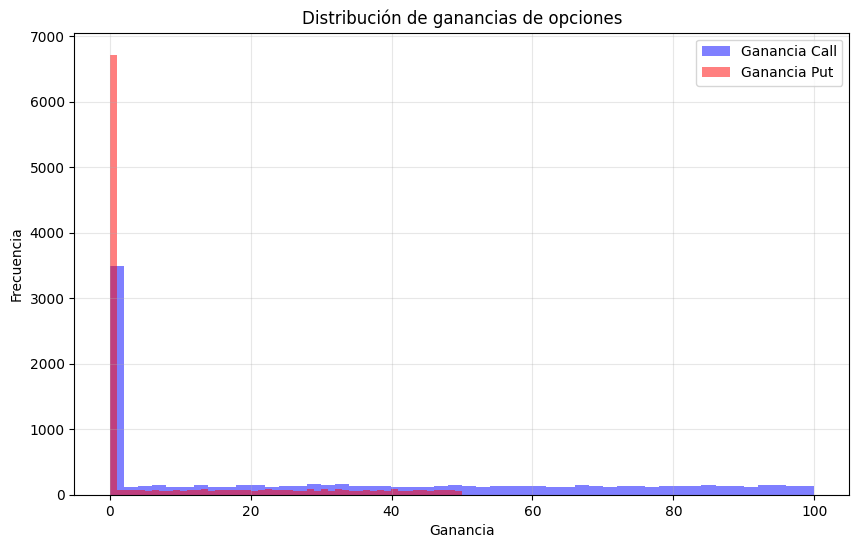

In [3]:
# Graficar la ganancia de las opciones call y put

plt.figure(figsize=(10, 6))

plt.hist(
    ganancia_call,
    bins=50,
    alpha=0.5,
    label="Ganancia Call",
    color="blue"
)

plt.hist(
    ganancia_put,
    bins=50,
    alpha=0.5,
    label="Ganancia Put",
    color="red"
)

plt.xlabel("Ganancia")
plt.ylabel("Frecuencia")
plt.title("Distribución de ganancias de opciones")
plt.legend()
plt.grid(alpha=0.3)
plt.show()   

## Trabajo en equipo 

## De un rango arbitrario a un modelo de precios

En esta sección el precio ya no se sortea uniforme: se simula con Movimiento Browniano Geométrico (GBM) bajo la medida neutral al riesgo, el modelo que sostiene a Black-Scholes-Merton. La idea nació en los años setenta con Black, Scholes y Merton, y hoy sigue siendo el punto de partida estándar para simular cómo se mueve el precio de un activo hacia el futuro.

La lógica, paso a paso:

1. Se parte del precio spot $S$.
2. Se le aplica una deriva ajustada por riesgo: $\left(r - \tfrac{1}{2}\sigma^2\right)$, multiplicada por el tiempo $T$.
3. Se le suma un componente aleatorio: $\sigma\sqrt{T}\,Z$, con $Z \sim N(0,1)$ representando el choque aleatorio de cada simulación.
4. Todo el exponente se aplica sobre $S$ para garantizar que el precio nunca sea negativo.

$$S_T = S \cdot \exp\left[\left(r - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right]$$

Se generan $M = 10{,}000$ trayectorias (una por cada valor de $Z$), y `ST` termina siendo un arreglo con los 10,000 precios posibles al vencimiento.

In [4]:
np.random.seed(42)
S = 100
k = 100
r = 0.05
sigma = 0.2
T = 1 
M = 10000

Z = np.random.normal(0, 1, M)

ST = S*np.exp((r - (0.5 * sigma ** 2)) * T + sigma * np.sqrt(T) * Z)
ST

array([113.8080226 , 100.23498965, 117.29684912, ...,  89.4882061 ,
       113.78643345, 117.21945676], shape=(10000,))

## Payoff sobre las trayectorias simuladas

Con `ST` ya generado bajo GBM, se calculan los payoffs igual que antes: $\max(S_T - K, 0)$ para el call y $\max(K - S_T, 0)$ para el put.

> Nota: en esta celda `simul_put` se calcula con `st` —la variable uniforme de la primera sección— y no con `ST`, la simulación GBM recién generada. Si la intención era comparar call y put sobre la misma trayectoria de precios, vale la pena revisar si fue un descuido al copiar el código de la sección anterior.

In [5]:
simul_call = np.maximum(ST - k,0)
simul_put = np.maximum(k - st, 0)

## Comparando las distribuciones simuladas

Este histograma compara la distribución de pagos del call y del put ya bajo el modelo GBM. A diferencia del primer histograma, aquí la forma sí refleja cómo se comporta realmente el precio de un activo bajo movimiento browniano geométrico: asimétrica, con cola larga hacia la derecha.

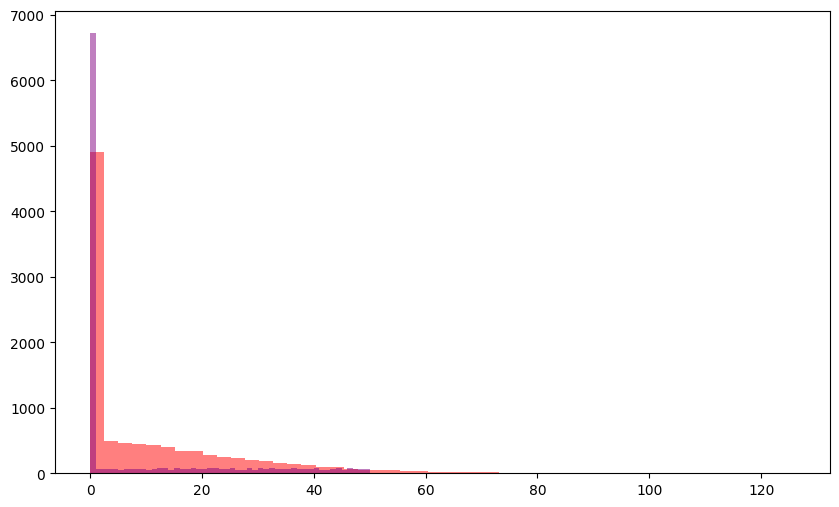

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    simul_call,
    bins=50,
    alpha=0.5,
    color="red"
    );

plt.hist(
    simul_put,
    bins=50,
    alpha=0.5,
    color="purple"
    );

## Ganancia promedio simulada

El promedio de los payoffs simulados es la estimación Monte Carlo de la ganancia esperada al vencimiento, bajo la medida neutral al riesgo. Para llegar al precio justo de la opción hoy, ese valor esperado se tendría que descontar a valor presente multiplicando por $e^{-rT}$; aquí solo se calcula la ganancia esperada, sin ese último paso de descuento.

In [7]:
simul_call.mean()

np.float64(10.985961590306978)

In [8]:
simul_put.mean()

np.float64(8.370473163435143)

## Punto de partida para el análisis de sensibilidad

Las siguientes celdas repiten la configuración de la simulación GBM —mismos parámetros y misma semilla— para dejar un punto de arranque limpio antes de mover un parámetro a la vez: volatilidad, tasa y plazo, y observar su efecto sobre la ganancia esperada de call y put.

In [9]:
np.random.seed(42)
S = 100
k = 100
r = 0.05
sigma = 0.2
T = 1 
M = 10000

Z = np.random.normal(0, 1, M)

ST = S*np.exp((r - (0.5 * sigma ** 2)) * T + sigma * np.sqrt(T) * Z)
ST



array([113.8080226 , 100.23498965, 117.29684912, ...,  89.4882061 ,
       113.78643345, 117.21945676], shape=(10000,))

In [10]:
simul_call = np.maximum(ST - k,0)
simul_put = np.maximum(k - st, 0)

## Sensibilidad a la volatilidad

Aquí se repite la simulación de $S_T$ para distintos valores de $\sigma$ (10%, 20%, 40%, 60%), manteniendo fijos $r$, $K$ y $T$, y se calcula la ganancia promedio de call y put en cada caso.

Entre más alta la volatilidad, más ancha es la distribución de $S_T$: hay más probabilidad de que el precio termine lejos del strike, en cualquier dirección. Eso favorece tanto al call como al put, porque ambos tienen la pérdida máxima limitada a cero —a mayor incertidumbre, mayor ganancia esperada para las dos opciones.

In [14]:
volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]
resultados_volatilidad = []

np.random.seed(42)
Z = np.random.normal(0, 1, M)

for volatilidad in volatilidades:
    ST = S * np.exp(
        (r - 0.5 * volatilidad**2) * T
        + volatilidad * np.sqrt(T) * Z
    )
    resultados_volatilidad.append({
        "Volatilidad": f"{volatilidad:.0%}",
        "Ganancia promedio Call": np.maximum(ST - k, 0).mean(),
        "Ganancia promedio Put": np.maximum(k - ST, 0).mean()
    })

pd.DataFrame(resultados_volatilidad).round(2)

,Volatilidad,Ganancia promedio Call,Ganancia promedio Put
0,10%,7.15,2.04
1,20%,10.99,5.89
2,30%,14.97,9.87
3,40%,18.97,13.87
4,50%,22.96,17.84


## Sensibilidad a la tasa libre de riesgo

Ahora se varía $r$ (5%, 10%, 20%), dejando $\sigma$ y $T$ fijos. La tasa entra en la deriva de GBM: una $r$ más alta empuja la distribución de $S_T$ hacia arriba, lo que favorece al call (su ganancia promedio sube) y perjudica al put (su ganancia promedio baja), porque el precio esperado se aleja hacia arriba del strike.

In [16]:
tasas = [0.05, 0.10, 0.15, 0.20]
resultados_tasa = []

np.random.seed(42)
Z = np.random.normal(0, 1, M)

for tasa in tasas:
    ST = S * np.exp(
        (tasa - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )
    resultados_tasa.append({
        "Tasa r": f"{tasa:.0%}",
        "Ganancia promedio Call": np.maximum(ST - k, 0).mean(),
        "Ganancia promedio Put": np.maximum(k - ST, 0).mean()
    })

pd.DataFrame(resultados_tasa).round(2)

,Tasa r,Ganancia promedio Call,Ganancia promedio Put
0,5%,10.99,5.89
1,10%,14.66,4.17
2,15%,18.99,2.84
3,20%,23.96,1.85


## Sensibilidad al plazo

Por último se varía el tiempo a vencimiento $T$ (0.25, 0.5, 1 y 2 años), con $r$ y $\sigma$ fijos en sus valores base. En GBM tanto la deriva como el componente aleatorio dependen de $T$ —el aleatorio escala con $\sqrt{T}$—, así que a mayor plazo, mayor dispersión de $S_T$. Igual que con la volatilidad, más tiempo significa más incertidumbre acumulada, lo que en general incrementa la ganancia promedio esperada de ambas opciones.

In [15]:
tiempos = [0.25, 0.5, 1, 1.5, 2]
tasa_base = 0.05
volatilidad_base = 0.20
resultados_tiempo = []

np.random.seed(42)
Z = np.random.normal(0, 1, M)

for plazo in tiempos:
    ST = S * np.exp(
        (tasa_base - 0.5 * volatilidad_base**2) * plazo
        + volatilidad_base * np.sqrt(plazo) * Z
    )
    resultados_tiempo.append({
        "Tiempo": plazo,
        "Ganancia promedio Call": np.maximum(ST - k, 0).mean(),
        "Ganancia promedio Put": np.maximum(k - ST, 0).mean()
    })

pd.DataFrame(resultados_tiempo).round(2)

,Tiempo,Ganancia promedio Call,Ganancia promedio Put
0,0.25,4.67,3.43
1,0.50,7.06,4.55
2,1.00,10.99,5.89
3,1.50,14.49,6.73
4,2.00,17.82,7.34


## Conclusión

Los tres análisis de sensibilidad muestran el mismo patrón de fondo: la ganancia esperada de call y put no depende solo de hacia dónde se espera que se mueva el precio, sino de cuánta incertidumbre hay alrededor de ese movimiento. Volatilidad y plazo aumentan esa incertidumbre y elevan el valor de ambas opciones; la tasa libre de riesgo, en cambio, mueve la dirección esperada del precio, y por eso afecta a call y put en sentidos opuestos. Es, en esencia, la misma intuición detrás de las griegas de Black-Scholes (Vega, Rho, Theta), solo que aquí se llega a ella por fuerza bruta, simulando miles de trayectorias en vez de resolver la fórmula cerrada.